<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/0904_%EC%84%B8%EC%85%98_%EB%AA%A8%EB%8D%B8%ED%9B%88%EB%A0%A8_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **모델 훈련 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch04 연습문제 1, 5, 9, 10
- 개념 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

### **1. 수백만 개의 특성을 가진 훈련 세트에서는 어떤 선형 회귀 알고리즘을 사용할 수 있을까요?**
___


### **2. 배치 경사 하강법을 사용하고 에포크마다 검증 오차를 그래프로 나타내봤습니다. 검증 오차가 일정하게 상승되고 있다면 어떤 일이 일어나고 있는 걸까요? 이 문제를 어떻게 해결할 수 있나요?**
___

검증 오차가 일정하게 상승되고 있다면 학습률이 너무 높아서 알고리즘이 발산하고 있다는 뜻이기 때문에 학습률을 낮춰서 다시 훈련시켜야 함.  

### **3. 릿지 회귀를 사용했을 때 훈련 오차가 검증 오차가 거의 비슷하고 둘 다 높았습니다. 이 모델에는 높은 편향이 문제인가요, 아니면 높은 분산이 문제인가요? 규제 하이퍼파라미터 $\alpha$를 증가시켜야 할까요 아니면 줄여야 할까요?**
___

훈련 오차와 검증 오차가 모두 높은 경우 과소적합을 의심할 수 있으며, 이는 높은 편향이 문제인 경우이다. 편향을 줄이기 위해서는 규제 하이퍼 파라미터 alpha를 줄여야한다.

### **4. 다음과 같이 사용해야 하는 이유는?**
___
- 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀
- 릿지 회귀 대신 라쏘 회귀
- 라쏘 회귀 대신 엘라스틱넷

1. 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀

일반 선형 회귀는 규제가 없어 계수가 지나치게 커지면서 과적합될 수 있다. 릿지 회귀는 L2 규제로 큰 계수에 패널티를 주어 모델의 복잡도와 과적합을 줄이고 일반화 성능을 높인다. 또한 다중공선성이 있을 때 계수를 더 안정적으로 추정할 수 있다.

2. 릿지 회귀 대신 라쏘 회귀

릿지는 계수의 크기를 줄이지만 보통 정확히 0으로 만들지는 않는다. 반면 라쏘는 L1 규제를 사용하여 중요하지 않은 변수의 계수를 0으로 만들 수 있어 변수 선택 효과가 있다.

3. 라쏘 회귀 대신 엘라스틱넷

라쏘는 상관관계가 높은 변수들이 있을 때 그중 일부 변수들만 임의적으 선택해 결과가 불안정할 수 있다. 엘라스틱넷은 L1과 L2 규제를 함께 사용하여 라쏘의 변수 선택 효과와 릿지의 안정성을 동시에 얻을 수 있다.

### **추가) 조기 종료를 사용한 배치 경사 하강법으로 iris 데이터를 활용해 소프트맥스 회귀를 구현해보세요(사이킷런은 사용하지 마세요)**


---



Early stopping!
Epoch: 100
Test Accuracy: 0.3333333333333333


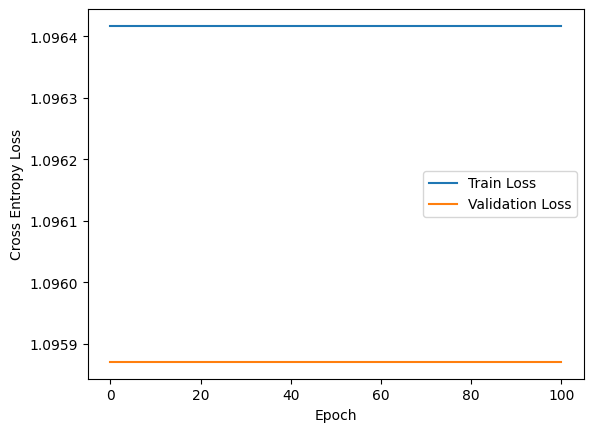

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Iris 데이터 불러오기
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

iris=pd.read_csv(url, header=None,names=columns)
iris=iris.dropna()

X=iris.iloc[:,:-1].values

# 문자열 클래스 -> 숫자 클래스
class_mapping={
    "Iris-setosa":0,
    "Iris-versicolor":1,
    "Iris-virginica":2
}

y=iris["class"].map(class_mapping).values

# 2. Train / Validation / Test 분리
# 클래스별로 30 /10 / 10개씩 나눔

rng=np.random.default_rng(42)

train_idx=[]
val_idx=[]
test_idx=[]

for cls in np.unique(y):
  idx=np.where(y==cls)[0]
  rng.shuffle(idx)

  train_idx.extend(idx[:30])
  val_idx.extend(idx[30:40])
  test_idx.extend(idx[40:])

rng.shuffle(train_idx)
rng.shuffle(val_idx)
rng.shuffle(test_idx)

X_train, y_train=X[train_idx], y[train_idx]
X_val, y_val=X[val_idx], y[val_idx]
X_test, y_test= X[test_idx], y[test_idx]

# 3. 표준화
# Train 데이터의 평균과 표준편차 사용

mean=X_train.mean(axis=0)
std=X_train.std(axis=0)

X_train=(X_train-mean)/std
X_val=(X_val-mean)/std
X_te=(X_test-mean)/std

# 4. 절편을 위한 1 추가

X_train=np.c_[np.ones(len(X_train)), X_train]
X_val=np.c_[np.ones(len(X_val)), X_val]
X_test=np.c_[np.ones(len(X_test)), X_test]

# 클래스 개수
n_classes=3


# 5. One-hot encoding 함수
def one_hot(y, n_classes):
  Y=np.zeros((len(y), n_classes))
  Y[np.arange(len(y)), y]=1
  return Y


Y_train=one_hot(y_train, n_classes)
Y_val=one_hot(y_val, n_classes)

# 6. Softmax 함수

def softmax(z):
  # overflow 방지를 위해 최댓값을 해줌
  z=z-np.max(z, axis=1, keepdims=True)

  exp_z=np.exp(z)

  return exp_z/np.sum(exp_z, axis=1, keepdims=True)

# 7. Cross Entropy Loss
def cross_entropy(Y,P):
  epsilon=1e-15

  return -np.mean(
      np.sum(Y*np.log(P+epsilon), axis=1)
  )

# 8. 배치 경사 하강법 + 조기 종료
rng=np.random.default_rng(42)

W=rng.normal(
    0,
    0.01,
    size=(X_train.shape[1], n_classes)
    )
learning_rate=0.1
max_epochs=10000

patience=100
tol=1e-4

best_val_loss=np.inf
best_W=W.copy()

wait=0

train_losses=[]
val_losses=[]

for epoch in range(max_epochs):

      # 전체 train 데이터를 한 번에 사용
      scores=X_train @ W

      probabilities=softmax(scores)

      # gradient
      gradient=(
          X_train.T@(probabilities-Y_train)
      ) / len(X_train)

      # 가중치 업데이트 W=W-learning_rate*gradient

      # Train Loss
      train_prob=softmax(X_train@W)

      train_loss=cross_entropy(
          Y_train,
          train_prob
      )

      # Validation loss
      val_prob=softmax(X_val@W)

      val_loss=cross_entropy(
          Y_val,
          val_prob
      )

      train_losses.append(train_loss)
      val_losses.append(val_loss)

      # 조기 종료
      if best_val_loss-val_loss>tol:
        best_val_loss=val_loss
        best_W=W.copy()
        wait=0
      else:
        wait+=1
      if wait>=patience:
        print("Early stopping!")
        print("Epoch:", epoch)

        break

# 가장 좋은 시점의 가중치 복원
W=best_W

# 9. Test 데이터 예측
test_prob=softmax(X_test@W)

y_pred=np.argmax(
          test_prob,
          axis=1
      )

accuracy=np.mean(y_pred==y_test)

print("Test Accuracy:", accuracy)

# 10. Loss 그래프
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()

plt.show()